# Netflix Movies & TV Shows - Exploratory Data Analysis



**Dataset:** Netflix Titles (Kaggle - Shivamb)
**Tool:** Python (pandas, matplotlib, seaborn)
**Author:** Nikita Parmar  

## Objective
To explore the Netflix dataset and uncover patterns in content type, ratings, country distribution, genre trends, and growth over time using Python and EDA techniques.

## 1. Importing Libraries
Importing pandas for data manipulation, and matplotlib/seaborn for visualisation.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Fail to read file as url
Reason: maybe because of relocation of file

In [3]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/netflix_titles.csv"

df = pd.read_csv(url)

HTTPError: HTTP Error 404: Not Found

## 2. Loading the Dataset
Dataset loaded from a local CSV file (source: Kaggle — Netflix Shows by Shivamb).

In [4]:
from google.colab import files
uploaded= files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [5]:
df = pd.read_csv("netflix_titles.csv")

In [6]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


* Analysis of above code
Looking at row 0 — Dick Johnson Is Dead. The cast column shows NaN.
Here NaN is not bad because A documentary about one real person often has no traditional cast — so NaN, it's expected data.

* Missing value ≠ always a data quality problem. Sometimes missing means "not applicable."

In [7]:
df.shape

(8807, 12)

* df.shape — rows and columns count
* The Dataset has 8807 rows and 12 columns

In [8]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


* df.dtypes — data type of each column
* date_added — It stored as a string like "September 25, 2021" but should be datetime.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


* df.info() — it gives a summary: column names, how many non-null values exist in each column, and data types all in one place.
* 'director' has most missing values               

## 3. Missing Value Analysis & Cleaning
Identified missing values across key columns.
- Director (~30% missing) — filled with 'Unknown' to preserve dataset size
- Cast (~10% missing) — filled with 'Unknown' as some titles genuinely have no cast
- Country (~6% missing) — filled with 'Unknown' to avoid assuming origin
- Date added — converted to datetime for time-based analysis
- Rating — removed erroneous duration values entered in wrong column

In [10]:
df.isnull().sum()


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


Missing %
* director - 30%
* cast - 10%
* country - 6%

In [11]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

* Filling missing values with another real value like Unknown or leave it as NaN

In [12]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,4
duration,3


## Insight:
"I identified missing values using isnull().sum(). For high-missing columns like director (30%) I chose not to drop rows as it would lose significant data. Instead I filled with 'Unknown' to preserve dataset integrity while being honest about data gaps."

In [13]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# Code info:
* str.strip():It removes extra spaces from the beginning and end of a text value.

In [14]:
df['date_added'].dtype

dtype('<M8[ns]')

* Converted 'date_added' column datatype to datetime
* used str.strip() to remove extra spaces from the begining and end of a text value

## 4. Univariate Analysis
Analysing individual columns to understand distributions before combining variables.

# Ques:
 How many Movies vs TV Shows are on Netflix?


In [15]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


/tmp/ipykernel_640/3993401935.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


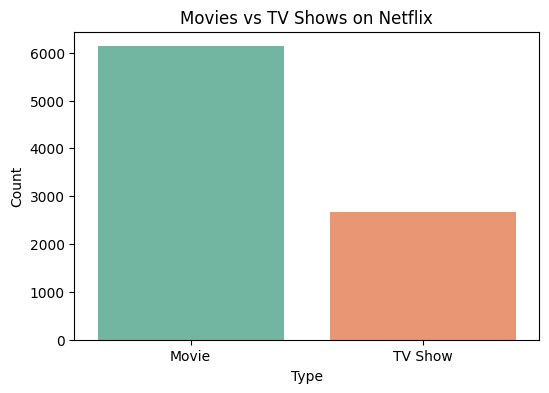

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

# Code info:
* plt.figure(figsize=(6,4)): Sets the size of the chart — width 6, height 4
* sns.countplot(...):	Draws a bar chart counting each category
* plt.title(...):	Adds a heading to the chart
* plt.xlabel / ylabel:	Labels the axes
* plt.show():	Displays the chart

## Insight:
 "Netflix's content library is dominated by _Movies_, which makes up approximately _70_% of all titles. This suggests that Netflix's strategy is focused on __Movies__ rather than _TV Shows_."

# Ques:
 What ratings does Netflix mostly carry?

In [17]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


 # Insight:
 Most common rating is TV-MA with 3207 rating count

 It contains mins also in rating section

In [18]:
df[df['rating'].isin(['74 min', '84 min', '66 min'])]['title']

,title
5541,Louis C.K. 2017
5794,Louis C.K.: Hilarious
5813,Louis C.K.: Live at the Comedy Store


In [19]:
df.loc[df['rating'].isin(['74 min', '84 min', '66 min']), 'rating'] = None

In [20]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


/tmp/ipykernel_640/1595485195.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='Set2')


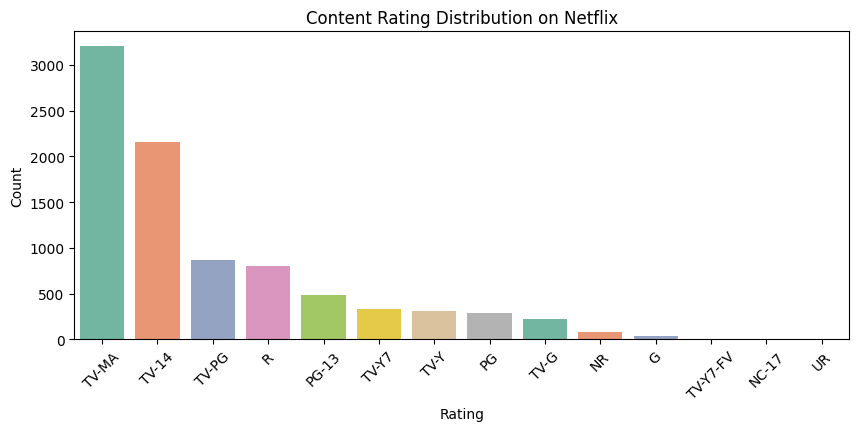

In [21]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='Set2')
plt.title('Content Rating Distribution on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Code info:
* order=df['rating'].value_counts().index: It sorts the bars from highest to lowest count so the most common rating appears first on the left, making the chart easier to read.

# Insight:
"Netflix content is heavily skewed towards mature audiences, with TV-MA (adult content) and TV-14 making up the majority of titles.This suggests Netflix primarily targets adults and teenagers rather than children and family audiences."

## 5. Bivariate Analysis
Combining columns to find patterns across content type, country, time, and genre.

# Ques:
Which countries produce the most Netflix content?

In [22]:
top_countries = df['country'].value_counts().head(10)
print(top_countries)

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


/tmp/ipykernel_640/3676133182.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Set2')


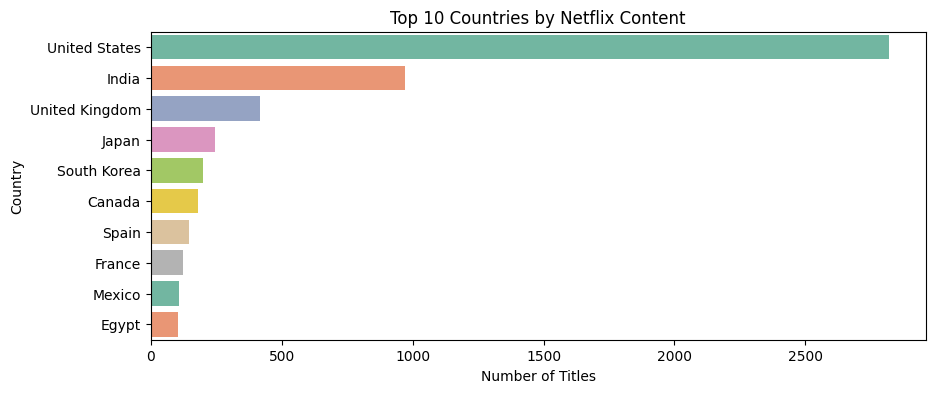

In [23]:
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)

plt.figure(figsize=(10,4))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Set2')
plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

# Insight:
"Netflix content is heavily concentrated in English-speaking markets, with the United States dominating by a significant margin, followed by India and the UK. This suggests Netflix has a strong focus on English language content while also investing in Hindi and international content to expand its global reach."

# Ques:
How has Netflix grown over the years — how many titles were added each year?

In [24]:
df['year_added'] = df['date_added'].dt.year
year_counts = df['year_added'].value_counts().sort_index()
print(year_counts)

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64


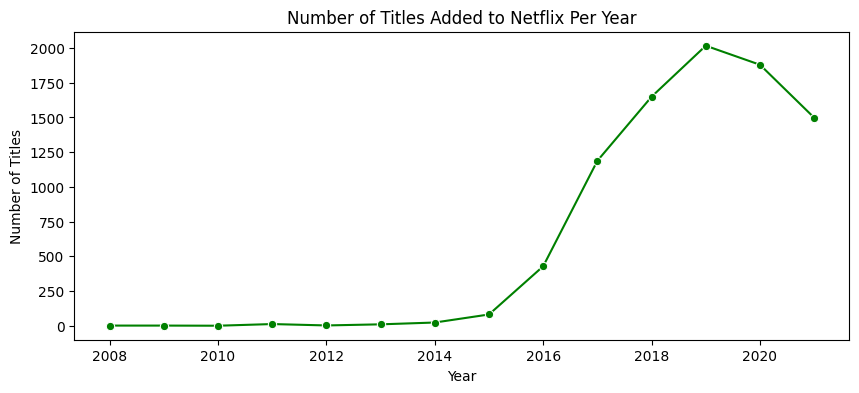

In [25]:
plt.figure(figsize=(10,4))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='green')
plt.title('Number of Titles Added to Netflix Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

# Insight:
"Netflix saw peak content addition in __2019__, followed by a noticeable decline from 2020 onwards, likely due to __COVID 19 pandemic__ disrupting global content production."

# Ques:
What are the top 10 genres on Netflix?

In [26]:
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
print(top_genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


# Code info:
* .str.split(', ')	Splits "Crime TV Shows, International TV Shows" into a list
* .explode()	Turns each item in the list into its own separate row

/tmp/ipykernel_640/2263132010.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='Set2')


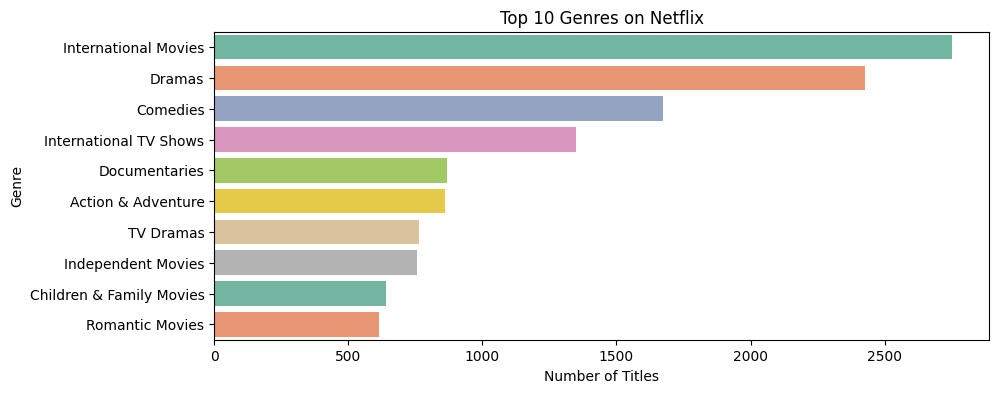

In [27]:
plt.figure(figsize=(10,4))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='Set2')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

# Insight:
"This reflects Netflix's strategy of targeting a global audience by investing heavily in international and locally produced content, while maintaining a strong library of universally popular genres like Dramas and Comedies."

## 6. Business Insights

1. **Content Type:** Netflix's library is dominated by Movies (~70%), suggesting a stronger focus on film content over TV Shows.

2. **Ratings:** TV-MA and TV-14 are the most common ratings, indicating Netflix primarily targets adult and teenage audiences rather than families or children.

3. **Country:** The United States dominates content production, followed by India and the UK. Netflix is investing in international content to grow its global subscriber base.

4. **Growth Trend:** Netflix peaked in content addition in 2019, followed by a decline likely caused by COVID-19 disrupting global production.

5. **Genres:** International Movies, Dramas, and Comedies dominate the library, reflecting Netflix's strategy of catering to both global and locally relevant audiences.